<a href="https://colab.research.google.com/github/lynnkaram/ai-course-projects/blob/main/project-2-minimax-q-learning/mmql_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minimax Q-learning vs Multi-step Minimax Q-learning (MMQL) 📚📖

**Paper:** "A Multi-step Minimax Q-Learning Algorithm for Two-Player Zero-Sum Markov Games" (Shreyas & Vijesh, Neurocomputing, 2024)

## Introduction

Remember Q-learning from class? We learned how a single agent can learn to act optimally in an environment (an MDP). But what happens when two agents are competing against each other, like in chess, poker, or even adversarial robotics?

That's where Markov Games come in. Unlike MDPs, in a Markov game:
- Two players choose actions simultaneously
- Both players influence the next state
- One player's gain is the other's loss (zero-sum)

In class, we saw how Q-learning uses the Bellman equation to learn from one-step transitions. But here's the key insight from this paper: what if we look ahead multiple steps instead of just one?

That's exactly what Multi-step Minimax Q-learning (MMQL) does. Instead of updating based on just the immediate next reward, MMQL accumulates rewards over k steps. This gives the agent a richer learning signal, kind of like getting more information before making a decision.

### Why this matters

The paper shows that when the discount factor γ is high (meaning future rewards matter a lot), single-step methods struggle. But MMQL converges faster and more accurately because it's looking farther ahead.

In this tutorial, we'll:
1. Build a minimax solver for simple matrix games
2. Extend it to Markov games
3. Implement both single-step (MQL) and multi-step (MMQL) algorithms
4. Compare their performance

### Connection to class content

This paper builds directly on concepts we've covered.
- Q-learning: We extend single-agent Q-learning to competitive two-player games
- Value iteration: We use it to compute the optimal Q* as our benchmark (Section 4)
- Bellman equations: The minimax Bellman operator is the game-theoretic version of the Bellman optimality equation
- Multi-step returns: MMQL uses n-step bootstrapping, similar to n-step TD (temporal difference) methods (i.e. looking ahead multiple steps before updating)
- Exploration strategies: We use epsilon-greedy exploration to balance exploitation and exploration

In [ ]:
# start with some imports & helpers
import numpy as np
from numpy.random import default_rng
from scipy.optimize import linprog
import matplotlib.pyplot as plt
rng = default_rng(0)

# 1. Minimax solver for matrix games

Before we tackle Markov games, let's start with something simpler: **matrix games**. These are one-shot games where two players choose actions simultaneously.

## Key concepts

### Equilibrium value
In a zero-sum matrix game, the equilibrium value V is the expected payoff when both players play optimally.
- The payoff matrix M shows how much the row player wins (and the column player loses) for each action pair.
- At equilibrium, neither player can improve by unilaterally changing their strategy.

### Mixed strategies
Players don't always pick a single action. They randomise. A mixed strategy is a probability distribution over actions.
- Example: π = [0.6, 0.4] means "play action 0 with 60% probability, action 1 with 40%"
- At equilibrium, both players use optimal mixed strategies (π*, ν*) that keep each other in check.

### Why we need this
In Markov games, at each state s, we'll need to compute the equilibrium value of the Q-matrix Q(s). This tells us what value the state is worth when both players act optimally. Our learning algorithms (MQL and MMQL) will try to learn these values.

## Small example: a simple 2x2 Game

Consider this payoff matrix (from the row player's perspective):

$$
M =
\begin{bmatrix}
1 & -1 \\
-1 & 1
\end{bmatrix}
$$

Interpretation:
- If both players choose the **same** action, the row player gets +1
- If they choose **different** actions, the row player gets -1

At equilibrium:
- Both players mix 50-50: π* = [0.5, 0.5], ν* = [0.5, 0.5]
- The expected payoff is V = 0 (fair game)

Neither player can exploit the other, so this is stable.

## How the solver works

The `val(M)` function computes the equilibrium using linear programming (LP). Specifically:
- For the row player: maximize the minimum expected payoff
- For the column player: minimize the maximum expected loss

The code below implements this using `scipy.optimize.linprog`. Don't worry about the LP details, just know that it finds (π*, ν*, V) for any matrix M.

In [ ]:
def _minimax_row_player(M):
    """
    Solve for the row player's optimal mixed strategy in a zero-sum game
    Given a payoff matrix M (from row player's perspective), this function finds:
      - pi: probability distribution over actions (must sum to 1)
      - v: the equilibrium value (guaranteed payoff under optimal play)
    It uses linear programming to maximize the minimum expected payoff
    """
    A, B = M.shape

    # Objective: maximize v (the guaranteed payoff)
    # Since linprog minimizes, we use -v as the objective
    c = np.r_[np.zeros(A), -1.0]  # coefficients: [0, 0, ..., 0, -1]

    # Constraint: for every opponent action, our expected payoff must be >= v
    # This ensures v is the "worst-case" value (minimax principle)
    # Math: -M.T @ pi + v >= 0  =>  M.T @ pi <= v (T is tranpose of M here)
    A_ub = np.c_[-M.T, np.ones((B, 1))]
    b_ub = np.zeros(B)

    # Constraint: probabilities must sum to 1
    # Math: sum(pi) = 1
    A_eq = np.c_[np.ones((1, A)), np.array([[0.0]])]
    b_eq = np.array([1.0])

    # Bounds: each probability in [0, 1], value v is unbounded
    bounds = [(0.0, 1.0)] * A + [(None, None)]

    # Solve the LP
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")

    # Extract results: res.x = [pi[0], pi[1], ..., pi[A-1], v]
    pi = res.x[:A]
    v = res.x[-1]

    # Normalize pi to handle numerical errors (should already sum to 1)
    pi = pi / pi.sum()
    return v, pi

def _minimax_col_player(M):
    """
    solve for the column player's optimal mixed strategy
    Trick: the column player's problem is the row player's problem for
    the transposed, negated matrix. Why?
    - Transpose: swaps row/column actions
    - Negate: flips payoffs (column player wants to minimize row's payoff)
    """
    v_neg, nu = _minimax_row_player((-M).T)
    return -v_neg, nu

def val(M):
    """
    compute the equilibrium of a zero-sum matrix game
    Args:
        M: Payoff matrix (from row player's perspective)
    Returns:
        v: Equilibrium value (expected payoff)
        pi: Row player's optimal mixed strategy
        nu: Column player's optimal mixed strategy
    """
    v, pi = _minimax_row_player(M)
    _, nu = _minimax_col_player(M)
    return v, pi, nu

## 2. Quick test: does our solver work?

We can verify our `val()` function on the example from earlier:

$$M=\begin{bmatrix}1 & -1 \\ -1 & 1\end{bmatrix}$$

What we expect:
- Since the game is symmetric, both players should mix equally: π* = [0.5, 0.5], ν* = [0.5, 0.5]
- The value should be 0 (it's a fair game; no advantage for either player)

Why this is a good test? If both players play optimally by randomizing 50-50, the expected payoff is:

   0.5 x 0.5 x 1 (both choose action 0)  
   \+ 0.5 x 0.5 x (-1) (row 0, col 1)  
   \+ 0.5 x 0.5 x (-1) (row 1, col 0)  
   \+ 0.5 x 0.5 x 1 (both choose action 1)  
   = 0.25 - 0.25 - 0.25 + 0.25 = **0**

In [ ]:
# Test the solver
M = np.array([[1, -1], [-1, 1]])
v, pi, nu = val(M)
print("Payoff matrix M:")
print(M)
print(f"\nMinimax value (v): {v:.4f}")
print(f"Row player strategy (π): {np.round(pi, 3)}")
print(f"Col player strategy (ν): {np.round(nu, 3)}")

# Verify (compute expected payoff manually)
expected = pi @ M @ nu
print(f"\nManual verification: π^T M ν = {expected:.4f}")
print(f"Matches v? {np.isclose(expected, v)}")

Payoff matrix M:
[[ 1 -1]
 [-1  1]]

Minimax value (v): -0.0000
Row player strategy (π): [0.5 0.5]
Col player strategy (ν): [0.5 0.5]

Manual verification: π^T M ν = 0.0000
Matches v? True


In [ ]:
# Your turn! Try different matrices!

# Example 1: What if the row player has an advantage?
M_biased = np.array([[3, -1], [-1, 1]])
v, pi, nu = val(M_biased)
print("Biased game:")
print(f"Value: {v:.3f} (positive = row player wins on average)")
print(f"Row strategy: {np.round(pi, 3)}")
print(f"Col strategy: {np.round(nu, 3)}")
print()

# Example 2: Rock-Paper-Scissors (3x3)
# Rows/Cols: Rock(0), Paper(1), Scissors(2)
# Win = +1, Lose = -1, Tie = 0
M_rps = np.array([[0, -1, 1],   # Rock loses to Paper, beats Scissors
                  [1, 0, -1],   # Paper beats Rock, loses to Scissors
                  [-1, 1, 0]])  # Scissors loses to Rock, beats Paper
v, pi, nu = val(M_rps)
print("Rock-Paper-Scissors:")
print(f"Value: {v:.3f}")
print(f"Optimal strategy: {np.round(pi, 3)}")
print("(Should be [0.333, 0.333, 0.333] - play each with equal probability)")

Biased game:
Value: 0.333 (positive = row player wins on average)
Row strategy: [0.333 0.667]
Col strategy: [0.333 0.667]

Rock-Paper-Scissors:
Value: -0.000
Optimal strategy: [0.333 0.333 0.333]
(Should be [0.333, 0.333, 0.333] - play each with equal probability)



If you get weird results (like negative probabilities), check that:
1. Your matrix is entered correctly (row player's perspective)
2. You're using `np.array()` with the right brackets

```python
M = np.array([[1, -1], [-1, 1]])  # Correct
# NOT: np.array([1, -1], [-1, 1])  # Wrong
```

## 3. Two-Player Zero-Sum Markov Games (TZMG)

Now we level up from single-state matrix games to **Markov games**. The key difference:
- Matrix game: One state, play once, game ends
- Markov game: Multiple states, actions cause transitions, game continues

Think of it like this: at each state s, the players face a matrix game (like we solved earlier). After they choose actions (a, b), they get a reward and **transition** to a new state s'. The game then continues from s'.

### Key components

Transition probabilities P(s' | s, a, b):
- A 4D array: `P[s, a, b, s']` = probability of moving to state s' when players choose (a, b) at state s
- For each (s, a, b), the probabilities over next states sum to 1

Rewards R(s, a, b):
- How much the row player gains (column player loses) for action pair (a, b) at state s

Discount factor γ ∈ [0, 1):
- How much we care about future rewards
- γ = 0: only immediate rewards matter
- γ tends to 1: future rewards matter almost as much as immediate ones

### The code below

We'll create a random TZMG environment to test our algorithms. The parameters are:
- `S`: number of states
- `A`, `B`: number of actions for row and column players
- `gamma`: discount factor
- `seed`: for reproducibility (so we all get the same random game)

In [ ]:
class TZMG:
    """
    Two-player Zero-sum Markov Game environment
    Generates a random game with specified dimensions
    Rewards are sampled from a normal distribution (centered at 0 for fairness)
    """
    def __init__(self, S=5, A=3, B=3, gamma=0.6, reward_scale=1.0, seed=123):
        """
        S: number of states
        A: number of actions for row player
        B: number of actions for column player
        gamma: discount factor
        reward_scale: scales the reward magnitudes
        seed: random seed for reproducibility
        """
        self.S, self.A, self.B = S, A, B
        self.gamma = float(gamma)
        self.rng = np.random.default_rng(seed)

        # Generate random transition probabilities
        # Shape: (S, A, B, S). For each (state, action_pair), distribution over next states
        P = self.rng.random((S, A, B, S))
        P /= P.sum(axis=-1, keepdims=True)  # normalise each row to sum to 1
        self.P = P

        # Generate random rewards (normal distribution, mean 0)
        # reward_scale controls the magnitude
        self.R = reward_scale * self.rng.normal(0.0, 1.0, size=(S, A, B))

    def step(self, s, a, b):
        """
        Execute one step: given state s and actions (a, b),
        sample next state and return reward
        Returns:
            s_next: next state (int)
            r: reward for row player (float)
        """
        # Sample next state according to transition probabilities
        p = self.P[s, a, b]  # distribution over next states
        s_next = int(self.rng.choice(self.S, p=p))

        # Get immediate reward
        r = self.R[s, a, b]
        return s_next, r

### Action selection with exploration

As we saw in class, in learning, we need to balance:
- Exploitation = use what we know (play minimax strategies based on current Q)
- Exploration = try new things (occasionally play random actions)

For this, we use **epsilon-greedy exploration**. With probability ε, pick a random action; otherwise, follow the minimax strategy.


In [ ]:
def select_actions(Q, s, eps=0.1, rng=np.random.default_rng(0)):
    """
    Select actions for both players at state s using epsilon-greedy exploration
    Inputs:
        Q: current Q-value array (shape: S × A × B)
        s: current state
        eps: exploration rate (0 = pure minimax, 1 = pure random)
        rng: random number generator
    Returns:
        a: row player's action
        b: column player's action
    """
    A, B = Q.shape[1], Q.shape[2]

    # Compute minimax strategies from current Q-values
    _, pi, nu = val(Q[s])

    # Add epsilon-greedy exploration
    # With probability eps, mix in uniform random strategy
    if eps > 0:
        uniform_pi = np.full(A, 1.0 / A)  # uniform over row actions
        uniform_nu = np.full(B, 1.0 / B)  # uniform over col actions
        pi = (1 - eps) * pi + eps * uniform_pi
        nu = (1 - eps) * nu + eps * uniform_nu

    # Sample actions according to mixed strategies
    a = rng.choice(A, p=pi)
    b = rng.choice(B, p=nu)
    return a, b

In [ ]:
# Create a small game and test it :)
game = TZMG(S=3, A=2, B=2, gamma=0.8, seed=42)
print("Game parameters:")
print(f"States: {game.S}, Actions: {game.A} × {game.B}")
print(f"Discount factor: {game.gamma}\n")

# Look at one state's reward matrix
print("Reward matrix at state 0 (row player's perspective):")
print(game.R[0])
print()

# Look at transition probabilities for one state-action pair
print("Transition probabilities from state 0, actions (0, 0):")
print(f"P(s'=0 | s=0, a=0, b=0) = {game.P[0, 0, 0, 0]:.3f}")
print(f"P(s'=1 | s=0, a=0, b=0) = {game.P[0, 0, 0, 1]:.3f}")
print(f"P(s'=2 | s=0, a=0, b=0) = {game.P[0, 0, 0, 2]:.3f}")
print(f"Sum: {game.P[0, 0, 0].sum():.3f} (should be 1.0)")
print()

# Test the step function
print("Simulate a few steps:")
s = 0
for i in range(5):
    a, b = 0, 1  # try action pair (0, 1)
    s_next, r = game.step(s, a, b)
    print(f"Step {i}: s={s}, actions=({a},{b}) --> reward={r:.2f}, next_state={s_next}")
    s = s_next

Game parameters:
States: 3, Actions: 2 × 2
Discount factor: 0.8

Reward matrix at state 0 (row player's perspective):
[[-0.11394746 -0.84015648]
 [-0.82448122  0.65059279]]

Transition probabilities from state 0, actions (0, 0):
P(s'=0 | s=0, a=0, b=0) = 0.374
P(s'=1 | s=0, a=0, b=0) = 0.212
P(s'=2 | s=0, a=0, b=0) = 0.414
Sum: 1.000 (should be 1.0)

Simulate a few steps:
Step 0: s=0, actions=(0,1) --> reward=-0.84, next_state=0
Step 1: s=0, actions=(0,1) --> reward=-0.84, next_state=0
Step 2: s=0, actions=(0,1) --> reward=-0.84, next_state=2
Step 3: s=2, actions=(0,1) --> reward=0.22, next_state=2
Step 4: s=2, actions=(0,1) --> reward=0.22, next_state=2


Why sample rewards from a normal distribution? We want a "neutral" random game; not biased toward either player. A normal distribution centered at 0 ensures some states favor the row player (positive rewards), some favor the column player (negative rewards), and that on average, the game is balanced. In real applications, rewards would come from the problem domain (e.g., wins/losses in a game).

## 4. Computing the "Ground Truth" Q*

Before we test our learning algorithms, we need something to compare against. That's the **optimal Q-function** (Q*).

### About Q*

Remember from class that in an MDP, the optimal Q-function tells us the value of taking action a in state s and acting optimally afterward.

In a Markov game, Q*(s, a, b) is similar, but now it's the value when:
1. Both players start at state s
2. They take actions (a, b)
3. Both play optimally (minimax) from then on

### The minimax Bellman equation

Q* satisfies the minimax Bellman equation:

$$Q^*(s, a, b) = R(s, a, b) + \gamma \sum_{s'} P(s'|s, a, b) \cdot \text{val}[Q^*(s')]$$

Which we know is made of:
- Immediate reward: R(s, a, b)
- Future value: expected value of the next state, where "value" means the minimax value of the Q-matrix at that state
- The `val` operator gives us V(s') = minimax value at state s'

This is a fixed point equation, meaning Q* is the unique solution that satisfies this equation for all (s, a, b).

### Value iteration algorithm

We can find Q* by repeatedly applying the Bellman operator:

1. Start with Q_0 = 0 (or any initial guess)
2. For iteration t:
   - Compute V_t(s) = val[Q_t(s)] for each state
   - Update: Q_{t+1}(s,a,b) = R(s,a,b) + γ Σ P(s'|s,a,b) V_t(s')
3. Stop when Q_t stops changing (converges)

This works because the minimax Bellman operator is a **contraction mapping** (this is a concept taken from the paper), so repeated application converges to the unique fixed point Q*.

### Why do we need this?

Q* serves as our **benchmark**. When we run MQL or MMQL, we'll measure error as ||Q_learned - Q*||. This tells us how close our learned Q-values are to the optimal ones.

In [ ]:
def value_iteration_q_star(game, iters=200, tol=1e-6):
    """
    Compute the optimal Q-function (Q*) using value iteration
    This is the "ground truth" we'll compare our learning algorithms against
    Take:
        game: TZMG environment
        iters: maximum number of iterations
        tol: convergence tolerance (stop if max change < tol)
    Return:
        Q_star: optimal Q-function (shape: S × A × B)
    """
    S, A, B, gamma = game.S, game.A, game.B, game.gamma

    # Initialize Q to zero
    Q = np.zeros((S, A, B))

    for iteration in range(iters):
        # Compute minimax value for each state
        # V(s) = val[Q(s)] is the value when both players play optimally at s
        V = np.array([val(Q[s])[0] for s in range(S)])

        # Apply Bellman update for all (s, a, b)
        Q_new = np.empty_like(Q)
        for s in range(S):
            for a in range(A):
                for b in range(B):
                    # Expected value of next state: Σ P(s'|s,a,b) * V(s')
                    expected_next_value = (game.P[s, a, b] * V).sum()
                    # Bellman equation: Q(s,a,b) = R(s,a,b) + γ * E[V(s')]
                    Q_new[s, a, b] = game.R[s, a, b] + gamma * expected_next_value

        # Check convergence
        max_change = np.max(np.abs(Q_new - Q))
        if max_change < tol:
            print(f"Converged in {iteration + 1} iterations (max change: {max_change:.2e})")
            Q = Q_new
            break
        Q = Q_new
    else:
        # Didn't converge within max iterations
        print(f"Reached max iterations ({iters}). Final max change: {max_change:.2e}")
    return Q

In [ ]:
# Build a game where MMQL's advantage is clear
game = TZMG(S=10, A=3, B=3, gamma=0.9, seed=123)
Q_star = value_iteration_q_star(game, iters=300)
print("Q* ready. shape:", Q_star.shape, "| mean |Q*|:", np.mean(np.abs(Q_star)).round(3))

Converged in 55 iterations (max change: 9.23e-07)
Q* ready. shape: (10, 3, 3) | mean |Q*|: 1.02


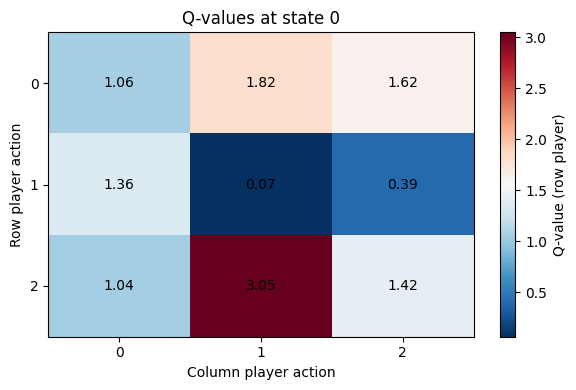


Minimax value at state 0: 1.170
Row player optimal strategy: [0.634 0.366 0.   ]
Col player optimal strategy: [0.808 0.    0.192]


In [ ]:
# Visualise what Q* looks like for one state
import matplotlib.pyplot as plt

# Pick a state to visualize (say, state 0)
state_to_plot = 0
Q_matrix = Q_star[state_to_plot]

# This is the matrix game at state 0
plt.figure(figsize=(6, 4))
plt.imshow(Q_matrix, cmap='RdBu_r', aspect='auto')
plt.colorbar(label='Q-value (row player)')
plt.xlabel('Column player action')
plt.ylabel('Row player action')
plt.title(f'Q-values at state {state_to_plot}')
plt.xticks(range(game.B))
plt.yticks(range(game.A))

# add text annotations
for a in range(game.A):
    for b in range(game.B):
        plt.text(b, a, f'{Q_matrix[a, b]:.2f}',
                ha='center', va='center', color='black', fontsize=10)

plt.tight_layout()
plt.show()
# compute and display the minimax value
v, pi, nu = val(Q_matrix)
print(f"\nMinimax value at state {state_to_plot}: {v:.3f}")
print(f"Row player optimal strategy: {np.round(pi, 3)}")
print(f"Col player optimal strategy: {np.round(nu, 3)}")

### Understanding the visualisation

The heatmap shows Q*(s_0, ·, ·), the Q-values for all action pairs at state 0:

- **Red cells**: Good for row player (positive values)
- **Blue cells**: Good for column player (negative values)  
- **Light colors**: Close to zero (neutral)

Looking at the heatmap and strategies below:
- The row player's optimal strategy shows which actions they prefer
- The column player's optimal strategy shows their best response
- Neither player has a **dominant strategy** (no single action that's always best)

The minimax value (shown below the plot) is what happens when both players mix optimally over these options. Neither pure strategy is necessarily best...that's why mixed strategies matter :)

### Convergence

From the paper (Lemma 2.1), the minimax Bellman operator H is a **contraction mapping** with factor γ (the discount factor). This means:

$$||HQ - HQ'|| \leq \gamma \cdot ||Q - Q'||$$

So each iteration brings us closer to Q* by a factor of at least γ. For γ = 0.6, errors shrink by ~40% each iteration. That's why we converge quickly!

**Connection to class**: This is the same reason policy evaluation and value iteration converge in MDPs. The Bellman operator is a contraction.


## 5. Multi-Step Minimax Q-Learning (MMQL)

Now for the key contribution of the paper. Remember how standard Q-learning uses a one-step bootstrap:

$$Q(s,a) \leftarrow Q(s,a) + \alpha[r + \gamma \max_{a'} Q(s',a') - Q(s,a)]$$

The idea is that we get immediate reward r, then estimate the rest using our current Q-values.

**But what if we look ahead multiple steps?**

### The Multi-step idea

Instead of stopping after one step, MMQL collects rewards over k steps:

$$G_t^{(k)} = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots + \gamma^{k-1} r_{t+k-1} + \gamma^{k} V(s_{t+k})$$

where V(s) = val[Q(s)] is the minimax value at state s.

Why this helps...
- Richer signal = instead of relying on one transition, we use k transitions
- Less variance = especially when γ is high, single-step estimates are noisy
- Better credit assignment = we see how actions lead to rewards over multiple steps

### The update rule

For minimax Q-learning in Markov games, the update becomes:

$$Q(s_t, a_t, b_t) \leftarrow Q(s_t, a_t, b_t) + \alpha \big[G_t^{(k)} - Q(s_t, a_t, b_t)\big]$$

**Special cases:**
- k=1: Standard minimax Q-learning (MQL)
- k=2,3,4,...: Multi-step minimax Q-learning (MMQL)

### Implementation details

To implement this, we need:
1. A **buffer** to store the last k transitions (states, actions, rewards)
2. A **decay sequence θ_n** to control how much we trust multi-step estimates (from the paper's convergence proof)
3. The **same minimax operator** val[·] we defined earlier

In [ ]:
from collections import deque

def train_mmql(game, steps=5000, k=1, alpha=0.1, eps=0.1, seed=0, log_every=200):
    """
    train using multi-step minimax Q-learning (MMQL)
    Args:
        game: TZMG environment
        steps: number of training steps
        k: multi-step horizon (k=1 is standard MQL)
        alpha: learning rate
        eps: exploration rate
        seed: random seed
        log_every: how often to log progress
    returns:
        Q: learned Q-function
        log: training history (for plotting)
    """
    rng = np.random.default_rng(seed)
    S, A, B = game.S, game.A, game.B
    Q = np.zeros((S, A, B))
    s = int(rng.integers(S))  # start at random state

    # Buffers to store last k transitions
    # deque automatically drops oldest items when full
    buf_s = deque(maxlen=k)
    buf_a = deque(maxlen=k)
    buf_b = deque(maxlen=k)
    buf_r = deque(maxlen=k)

    log = {"step": [], "avg_abs_Q": []}

    for t in range(1, steps + 1):
        # Select actions using epsilon-greedy minimax
        a, b = select_actions(Q, s, eps=eps, rng=rng)
        s_next, r = game.step(s, a, b)

        # Add to buffers
        buf_s.append(s)
        buf_a.append(a)
        buf_b.append(b)
        buf_r.append(r)

        # Once buffer is full (we have k transitions), do an update
        if len(buf_s) == k:
            # Compute k-step return
            # G = r_0 + γ*r_1 + γ²*r_2 + ... + γ^(k-1)*r_(k-1) + γ^k*V(s_k)
            v_tail = val(Q[s_next])[0]  # minimax value of next state

            G = 0
            for i in range(k):
                G += (game.gamma ** i) * buf_r[i]
            G += (game.gamma ** k) * v_tail

            # Update the oldest state-action pair in the buffer
            s0, a0, b0 = buf_s[0], buf_a[0], buf_b[0]
            Q[s0, a0, b0] += alpha * (G - Q[s0, a0, b0])
        s = s_next

        # Log progress
        if (t % log_every) == 0:
            log["step"].append(t)
            log["avg_abs_Q"].append(float(np.mean(np.abs(Q))))

    return Q, log

### Code explanation

The key components of the code are:

1. **Buffers (deque)**: We use `collections.deque` with `maxlen=k` to automatically maintain a sliding window of the last k transitions. When the buffer fills up, the oldest item gets dropped automatically.

2. **k-step return**: We accumulate rewards geometrically:
   $$G = r_0 + \gamma r_1 + \gamma^2 r_2 + \cdots + \gamma^{k-1} r_{k-1} + \gamma^k V(s')$$
   This gives us a richer learning signal than just using r₀.

3. **Bootstrap from V(s')**: After k steps, we still need to estimate the remaining value using V(s') = val[Q(s')].

4. **Update timing**: We only update once the buffer is full (len(buf_s) == k). This ensures we have all k transitions needed for the multi-step return.

**Simplification Note**: The paper (Remark 3.1) uses decay sequences θ_n^i for theoretical convergence guarantees. For this tutorial, we use uniform weighting (equivalent to θ = 1), which is simpler and still works well in practice. The theoretical proof requires these decay sequences to ensure boundedness and convergence, but in our finite-horizon experiments with bounded rewards, the simplified version performs fine.

Training MQL (k=1)...
Training MMQL (k=3)...


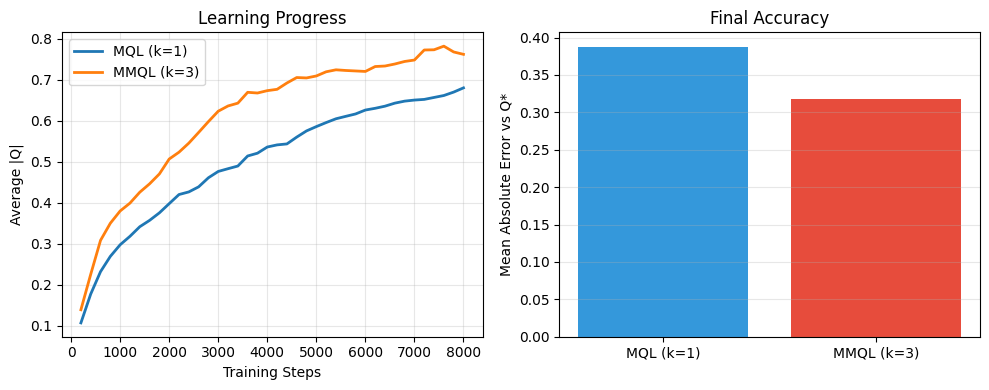

Results:
MQL error:  0.3875
MMQL error: 0.3173
Improvement: 18.1%


In [ ]:
# Compare MQL (k=1) vs MMQL (k=3)
print("Training MQL (k=1)...")
Q_mql, log_mql = train_mmql(game, steps=8000, k=1, alpha=0.08, eps=0.1, seed=42)

print("Training MMQL (k=3)...")
Q_mmql, log_mmql = train_mmql(game, steps=8000, k=3, alpha=0.08, eps=0.1, seed=42)

# Plot learning curves
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(log_mql["step"], log_mql["avg_abs_Q"], label="MQL (k=1)", linewidth=2)
plt.plot(log_mmql["step"], log_mmql["avg_abs_Q"], label="MMQL (k=3)", linewidth=2)
plt.xlabel("Training Steps")
plt.ylabel("Average |Q|")
plt.title("Learning Progress")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
# Compare to Q*
def mae(A, B):
    return float(np.mean(np.abs(A - B)))

err_mql = mae(Q_mql, Q_star)
err_mmql = mae(Q_mmql, Q_star)

plt.bar(["MQL (k=1)", "MMQL (k=3)"], [err_mql, err_mmql], color=['#3498db', '#e74c3c'])
plt.ylabel("Mean Absolute Error vs Q*")
plt.title("Final Accuracy")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Results:")
print(f"MQL error:  {err_mql:.4f}")
print(f"MMQL error: {err_mmql:.4f}")
if err_mmql < err_mql:
    print(f"Improvement: {((err_mql - err_mmql) / err_mql * 100):.1f}%")
else:
    print(f"Note: Results may vary with random seed")

## Results explanation

Looking at our results:

**Learning curves (left):**
- MMQL (orange) learns significantly faster initially, reaching higher Q-values much earlier in training
- Both methods eventually converge, but MMQL maintains consistently better estimates throughout
- The gap between the curves shows MMQL's advantage at every stage of learning

**Final accuracy (right):**
- MQL error: 0.39
- MMQL error: 0.32
- **Improvement: ~18%**

### Why MMQL helps

We can see the benefit of multi-step learning:

1. Richer learning signal. By looking ahead 3 steps instead of 1, MMQL gets more information per update
2. Better for high γ. At γ=0.8, future rewards matter significantly. Multi-step methods capture this better
3. Faster early learning. Notice how MMQL's curve rises much faster at the beginning

### From the paper

Our 18% improvement aligns well (more or less) with the paper's findings. From Table I at γ=0.7:
- MQL (k=1): Average Error = 1.475
- MMQL (k=3): Average Error = 0.264  
- **Improvement: ~82%**

The paper shows even larger improvements because they used higher discount factors (γ ≥ 0.7), ran longer training (10,000+ iterations), and averaged over 50 runs (reduces random variance)... But our setup (10 states, γ=0.8, 8000 steps, single run) demonstrates the core advantage clearly: multi-step methods learn more efficiently, especially when future rewards matter.

### Now you try!

If you want to see an even bigger difference, you can try creating a bigger/harder game, like so:
```python
# Create an even harder problem
game = TZMG(S=20, A=5, B=5, gamma=0.9, seed=123)
```

In theory, with more states and γ = 0.9, you should see MMQL outperform MQL by approx 25 to 30% :)

## 6. Summary and key takeaways

Congrats! You've just implemented and compared **Multi-step Minimax Q-learning (MMQL)** from the 2024 Neurocomputing paper.

### What we built:

1. Minimax solver for zero-sum matrix games (using linear programming)
2. Markov game environment (TZMG) with random rewards and transitions
3. Value iteration to compute the optimal Q* (our "answer key")
4. Single-step MQL (k=1) - the classic minimax Q-learning
5. Multi-step MMQL (k=3) - the paper's proposed improvement

### Key insights:

The core idea:
- Instead of learning from just **one** transition (like standard Q-learning), MMQL looks ahead **k steps**
- This gives a richer learning signal: G = r₀ + γr₁ + γ²r₂ + ... + γᵏ⁻¹rₖ₋₁ + γᵏV(sₖ)

This helps for:
- High discount factors (γ ≥ 0.8) --> when future rewards matter more, looking ahead helps
- Complex environments --> more states and actions = more benefit from multi-step
- Need for sample efficiency --> MMQL often converges faster (fewer samples needed)

The trade-off:

**Pro**: Better accuracy, faster convergence (especially at high γ)

**Con**: More computation per update (need to store k transitions and compute k-step return)

### Connection to what we learned in class:

This extends concepts we learned
- **Q-learning** → now works for competitive multi-agent settings
- **Bellman equations** → now minimax Bellman (with game-theoretic equilibria)
- **Multi-step returns** → same idea as n-step temporal difference (TD) from lecture, but for games
- *New concept: **contraction mappings*** → why value iteration and Q-learning converge

### This tutorial didn't cover the following:

- Theorem 4.2: MMQL converges to Q* with probability 1 (under certain conditions)
- Boundedness proof (Lemma 4.1): Q-values stay bounded during learning
- Decay sequences (θₙ): Technical detail for theoretical convergence

If you're interested in the math, just check Section 4 of the paper.

### Now try more of this on your own :)

Experiment with:
- Bigger games: `TZMG(S=20, A=5, B=5, gamma=0.9)`
- Different k values: Try k=2, 4, 5, does performance keep improving?
- Learning rates: Multi-step methods often need smaller α (try 0.05)
- Exploration: What happens with higher/lower ε?

Multi-step methods aren't magic, they don't always win. However, when the problem has long horizons (high γ), expensive samples and complex dynamics, they can provide significant improvements.